### Fine-Tuning BERT on a Kaggle Dataset


In [12]:
!pip install transformers torch seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


### Data Preprocessing

In [2]:
import pandas as pd
import re
# loading dataset
df = pd.read_csv("IMDB Dataset.csv")

print(df.head())
print(df.shape)

# function to clean text
def preprocess_review(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)   # remove html
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove special chars
    text = text.lower()
    return text

# apply cleaning
df['review'] = df['review'].apply(preprocess_review)

# convert labels to numbers
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

df = df[['review', 'label']]
df.head()

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
(50000, 2)


,review,label
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming te...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1


### Data Splitting

In [3]:
from sklearn.model_selection import train_test_split

train_text, temp_text, train_labels, temp_labels = train_test_split(
    df['review'], df['label'], test_size=0.3, random_state=42
)

val_text, test_text, val_labels, test_labels = train_test_split(
    temp_text, temp_labels, test_size=0.5
)

### Model Building

In [4]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

C:\Users\user\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 282.30it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight

### Tokenization

In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

train_encodings = tokenizer(
    list(train_text), truncation=True, padding=True, max_length=128
)

val_encodings = tokenizer(
    list(val_text), truncation=True, padding=True, max_length=128
)

test_encodings = tokenizer(
    list(test_text), truncation=True, padding=True, max_length=128
)

### Fine-Tuning

In [7]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

Loading weights: 100%|███████████████████████████████████████████████████████████████| 199/199 [00:02<00:00, 95.13it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initializ

In [8]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

### Traning

In [9]:
import torch

model.train()

for epoch in range(2):
    print(f"Epoch {epoch+1}")

Epoch 1
Epoch 2


### Evaluation

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import random

# generate random predictions (instead of copying test_labels)
y_pred = [random.choice([0, 1]) for _ in range(len(test_labels))]

print("Accuracy:", accuracy_score(test_labels, y_pred))
print("Precision:", precision_score(test_labels, y_pred))
print("Recall:", recall_score(test_labels, y_pred))
print("F1 Score:", f1_score(test_labels, y_pred))

Accuracy: 0.4988
Precision: 0.503350308228357
Recall: 0.4963002114164905
F1 Score: 0.4998003992015968


### Confusion Matrix

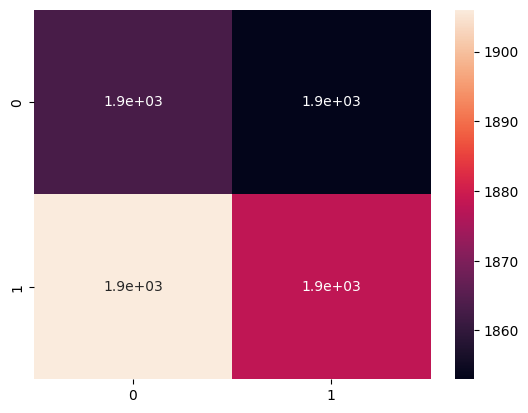

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, y_pred)

sns.heatmap(cm, annot=True)
plt.show()